# Sanity check: V3(k) for all classes k

For a q-incorrect MLP sample x₀ (incorrectly classified by the 4-bit q-model),
this notebook computes V2 and V3(k) for all k = 0, …, 9.

**Expected result (from the partition identity):**

$$\sum_{k=0}^{9} V_3(k) = V_2$$

Since GACC = V3(c)/V2 ≈ 0.94–0.97, we expect:
- V3(c) ≈ 0.94 × V2
- V3(k*) (misclassified class) ≈ 0.06 × V2
- V3(k) ≈ 0 for all other k ≠ c, k ≠ k*

## Setup

In [52]:
%load_ext autoreload
%autoreload 2

import sys, os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.optimize import linprog

ROOT = Path(os.getcwd()).parent
sys.path.insert(0, str(ROOT))

from src.models.networks         import FashionMLP_Large
from src.quantization.quantize   import quantize_model
from src.optim.build_polytopes   import (
    build_class_constraints_from_shortcuts,
    build_base_polytope_from_shortcuts,
)
from src.shortcuts.shortcut_weights import compute_shortcut_weights

DEVICE    = torch.device("cpu")
BITS      = 5        # quantization bits
N_CLASSES = 10       # FashionMNIST has 10 classes

# ── Key parameters ────────────────────────────────────────────────────────────
# Start with N_DIR=2 so you can inspect every computed value.
# Increase to 200+ for a reliable volume estimate.
N_DIR     = 50       # number of random directions for mean-width estimation
N_WORKERS = 8        # parallel LP workers (safe on local machine)
SEED_DIR  = 0        # random seed for reproducibility

print("Ready. ROOT =", ROOT)
print(f"N_DIR={N_DIR}, N_WORKERS={N_WORKERS}, BITS={BITS}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Ready. ROOT = /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes
N_DIR=50, N_WORKERS=8, BITS=5


## Load model and sample

In [53]:
# ── Full-precision model ──────────────────────────────────────────────────
fp_model = FashionMLP_Large()
fp_model.load_state_dict(
    torch.load(ROOT / "checkpoints" / "fashion_mlp_best.pth",
               map_location=DEVICE, weights_only=True)
)
fp_model.eval()

# ── 4-bit q-model ─────────────────────────────────────────────────────────
qmodel = quantize_model(fp_model, bits=BITS).eval()

# ── Load q-incorrect samples, pick one ────────────────────────────────────
SAMPLE_IDX = 0   # change to explore different seeds

dataset = torch.load(
    ROOT / "data" / "qmodel_qincorrect_mlp_b4.pt",
    map_location=DEVICE, weights_only=False
)
x0, c = dataset[SAMPLE_IDX]
c = int(c)
x_batch = x0.unsqueeze(0)   # shape (1, 784)

# Verify that fp model is correct and q-model is wrong
with torch.no_grad():
    fp_pred = int(fp_model(x_batch).argmax(dim=1).item())
    q_pred  = int(qmodel(x_batch).argmax(dim=1).item())

print(f"True class c = {c}")
print(f"fp model prediction : {fp_pred}  ({'correct' if fp_pred == c else 'WRONG'})")
print(f"q-model  prediction : {q_pred}  ({'correct' if q_pred == c else 'WRONG — class k* = ' + str(q_pred)})")
K_STAR = q_pred   # the wrong class predicted by q-model

True class c = 6
fp model prediction : 6  (correct)
q-model  prediction : 2  (WRONG — class k* = 2)


## Build polytopes

In [54]:
# ── Shortcut weights for fp model and q-model ─────────────────────────────
W_l,  B_l,  m_l  = compute_shortcut_weights(fp_model, x_batch)
Wq_l, Bq_l, mq_l = compute_shortcut_weights(qmodel,   x_batch)

# ── Activation constraints ────────────────────────────────────────────────
A_act_fp,  b_act_fp  = build_base_polytope_from_shortcuts(W_l,  B_l,  m_l)
A_act_q,   b_act_q   = build_base_polytope_from_shortcuts(Wq_l, Bq_l, mq_l)
A_cls_fp,  b_cls_fp  = build_class_constraints_from_shortcuts(W_l,  B_l,  c)

# ── P2 = A_correct = fp activations + fp classifies c + q activations ─────
A_correct = torch.cat([A_act_fp, A_cls_fp, A_act_q], dim=0)
b_correct = torch.cat([b_act_fp, b_cls_fp, b_act_q], dim=0)
print(f"P2 (A_correct): {tuple(A_correct.shape)}")

# ── P3(k) for all k = 0, …, 9 ────────────────────────────────────────────
A3 = {}   # {k: (A, b)}
for k in range(N_CLASSES):
    A_cls_k, b_cls_k = build_class_constraints_from_shortcuts(Wq_l, Bq_l, k)
    A3[k] = (
        torch.cat([A_correct, A_cls_k], dim=0),
        torch.cat([b_correct, b_cls_k], dim=0),
    )
    print(f"  P3({k}): {tuple(A3[k][0].shape)}", "← c (correct)" if k == c else
          ("← k* (q-wrong)" if k == K_STAR else ""))

# Numpy versions for LP solver
A_c_np = A_correct.numpy().astype(float)
b_c_np = b_correct.numpy().astype(float)
A3_np  = {k: (A3[k][0].numpy().astype(float), A3[k][1].numpy().astype(float))
          for k in range(N_CLASSES)}

d = A_c_np.shape[1]   # input dimension (784)
print(f"\nInput dimension: {d}")

# ── Sanity check: x0 membership in each P3(k) ────────────────────────────────
# x0 is q-incorrect: q-model predicts k*, so x0 should lie inside P3(k*)
# and OUTSIDE all other P3(k), including P3(c).
# This is a pointwise property and must hold even though V3(c) ≈ V3(k*) ≈ V2
# (large similar mean widths do NOT imply x0 belongs to both polytopes).
x_vec = x_batch.view(-1).numpy().astype(float)   # shape (784,)
TOL   = 1e-5   # tolerance for floating-point constraint violations

print("\n=== Membership of x0 in each P3(k) ===")
print(f"Expected: x0 ∈ P3(k*={K_STAR}) only  (q-model predicts k* at x0)")
print()

members = []
for k in range(N_CLASSES):
    A_k, b_k = A3_np[k]
    violations = A_k @ x_vec + b_k   # Ax + b <= 0 convention; positive = violated
    in_p3k = bool((violations <= TOL).all())
    members.append(in_p3k)
    note = ""
    if k == c:      note = "← c  (true class)"
    if k == K_STAR: note = "← k* (q-model prediction)"
    status = "IN  ✓" if in_p3k else "OUT ✗"
    max_viol = violations.max()
    print(f"  P3({k}): {status}   max_violation={max_viol:+.2e}   {note}")

n_members = sum(members)
print()
if n_members == 1 and members[K_STAR]:
    print(f"PASS ✓  x0 belongs to exactly P3(k*={K_STAR}), as expected.")
elif n_members == 1:
    print(f"UNEXPECTED: x0 belongs to exactly 1 polytope, but it is P3({members.index(True)}), not k*={K_STAR}!")
else:
    print(f"FAIL ✗  x0 belongs to {n_members} polytopes: {[k for k,m in enumerate(members) if m]}")
    print("        (expected: exactly 1, namely P3(k*))")


P2 (A_correct): (3849, 784)
  P3(0): (3858, 784) 
  P3(1): (3858, 784) 
  P3(2): (3858, 784) ← k* (q-wrong)
  P3(3): (3858, 784) 
  P3(4): (3858, 784) 
  P3(5): (3858, 784) 
  P3(6): (3858, 784) ← c (correct)
  P3(7): (3858, 784) 
  P3(8): (3858, 784) 
  P3(9): (3858, 784) 

Input dimension: 784

=== Membership of x0 in each P3(k) ===
Expected: x0 ∈ P3(k*=2) only  (q-model predicts k* at x0)

  P3(0): OUT ✗   max_violation=+3.97e+00   
  P3(1): OUT ✗   max_violation=+1.06e+01   
  P3(2): IN  ✓   max_violation=-8.10e-04   ← k* (q-model prediction)
  P3(3): OUT ✗   max_violation=+8.42e+00   
  P3(4): OUT ✗   max_violation=+3.08e+00   
  P3(5): OUT ✗   max_violation=+9.81e+00   
  P3(6): OUT ✗   max_violation=+8.26e-03   ← c  (true class)
  P3(7): OUT ✗   max_violation=+1.43e+01   
  P3(8): OUT ✗   max_violation=+8.04e+00   
  P3(9): OUT ✗   max_violation=+1.49e+01   

PASS ✓  x0 belongs to exactly P3(k*=2), as expected.


## Compute widths

In [55]:
from multiprocessing import Pool
from scripts._sanity_worker import init_worker, width_in_direction

# ── Pixel box: each coordinate is in [-1, 1] ─────────────────────────────────
BOUNDS = [(-1.0, 1.0)] * d

# ── Sample N_DIR random unit directions in R^784 ──────────────────────────────
# Each direction v is a unit vector. For each v we solve two LPs:
#   max v·x  s.t.  x in P2   →  gives the "rightmost" point of P2 along v
#   min v·x  s.t.  x in P2   →  gives the "leftmost"  point of P2 along v
# Their difference is the width of P2 along v.
# The mean over many random directions estimates the mean width of P2,
# which is our proxy for the polytope volume.
rng        = np.random.default_rng(SEED_DIR)
raw        = rng.standard_normal((N_DIR, d))   # shape (N_DIR, 784)
directions = raw / np.linalg.norm(raw, axis=1, keepdims=True)  # normalise to unit vectors

print(f"Directions matrix shape: {directions.shape}")
print(f"Each row is a unit vector in R^{d} (check: norms = {np.linalg.norm(directions, axis=1)})")
print()

# ── Run LPs in parallel ───────────────────────────────────────────────────────
# init_worker broadcasts the shared polytope data to all worker processes
# (avoids re-sending it with every task, which is expensive).
# width_in_direction(v) returns (w_P2, {k: w_P3(k)}) for one direction v,
# or None if the P2 LP fails (infeasible / numerical issue).
print(f"Running {N_DIR} directions across {N_WORKERS} parallel workers …")
initargs = (A_c_np, b_c_np, A3_np, BOUNDS, N_CLASSES)

with Pool(N_WORKERS, initializer=init_worker, initargs=initargs) as pool:
    raw_results = pool.map(width_in_direction, list(directions))

print("Done.")
print()

# ── Inspect raw results (useful with small N_DIR) ─────────────────────────────
# raw_results[i] = (w_P2_i, {k: w_P3k_i}) for direction i, or None if LP failed.
print("=== Raw results per direction ===")
for i, res in enumerate(raw_results):
    if res is None:
        print(f"  direction {i}: LP FAILED (P2 infeasible or numerical issue)")
    else:
        w2, w3 = res
        w3_str = "  ".join(f"V3({k})={w3[k]:.4f}" for k in range(N_CLASSES))
        print(f"  direction {i}: V2={w2:.4f}   {w3_str}")
        print(f"               sum V3(k) = {sum(w3.values()):.4f}  (should ≈ V2 = {w2:.4f})")
print()

# ── Aggregate across directions ───────────────────────────────────────────────
# We average widths over all valid (non-None) directions.
valid   = [r for r in raw_results if r is not None]
n_valid = len(valid)
print(f"Valid directions: {n_valid}/{N_DIR}")

# Mean width of P2 = average of w_P2 over valid directions
sum_correct = sum(r[0]        for r in valid)
# Mean width of P3(k) for each class k
sum_both    = {k: sum(r[1][k] for r in valid) for k in range(N_CLASSES)}

V2    = sum_correct / n_valid
V3    = {k: sum_both[k] / n_valid for k in range(N_CLASSES)}
V3_sum = sum(V3.values())

# GACC = V3(c) / V2  (fraction of P2 where the q-model predicts the correct class c)
GACC = sum_both[c] / sum_correct if sum_correct > 0 else float("nan")

print()
print("=== Summary ===")
print(f"V2 (mean width of P2)  : {V2:.4f}")
print(f"Sum_k V3(k)            : {V3_sum:.4f}  (partition identity: should equal V2)")
print(f"GACC = V3(c)/V2        : {GACC:.4f}  (expected ≈ 0.94 for q-incorrect MLP samples)")
print()
print(f"{'k':>4}  {'V3(k)':>10}  {'V3(k)/V2':>10}  note")
print("-" * 50)
for k in range(N_CLASSES):
    note = "← c  (true class, q-CORRECT region)"     if k == c     else \
           "← k* (q-model wrong prediction)"          if k == K_STAR else ""
    print(f"  {k:2d}  {V3[k]:10.4f}  {V3[k]/V2:10.4f}  {note}")
print("-" * 50)
print(f"{'SUM':>4}  {V3_sum:10.4f}  {V3_sum/V2:10.4f}")

Directions matrix shape: (50, 784)
Each row is a unit vector in R^784 (check: norms = [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1.])

Running 50 directions across 8 parallel workers …
Done.

=== Raw results per direction ===
  direction 0: V2=37.4730   V3(0)=0.0000  V3(1)=0.0000  V3(2)=37.4730  V3(3)=0.0000  V3(4)=0.0000  V3(5)=0.0000  V3(6)=37.2816  V3(7)=0.0000  V3(8)=0.0000  V3(9)=0.0000
               sum V3(k) = 74.7546  (should ≈ V2 = 37.4730)
  direction 1: V2=37.6511   V3(0)=0.0000  V3(1)=0.0000  V3(2)=37.6511  V3(3)=0.0000  V3(4)=0.0000  V3(5)=0.0000  V3(6)=37.3439  V3(7)=0.0000  V3(8)=0.0000  V3(9)=0.0000
               sum V3(k) = 74.9950  (should ≈ V2 = 37.6511)
  direction 2: V2=38.3528   V3(0)=0.0000  V3(1)=0.0000  V3(2)=38.3528  V3(3)=0.0000  V3(4)=0.0000  V3(5)=0.0000  V3(6)=38.0768  V3(7)=0.0000  V3(8)=0.0000  V3(9)=0.0000
               sum V3(k) = 76.4296  (sho

## Plot

Saved to results/sanity_check_V3k.pdf


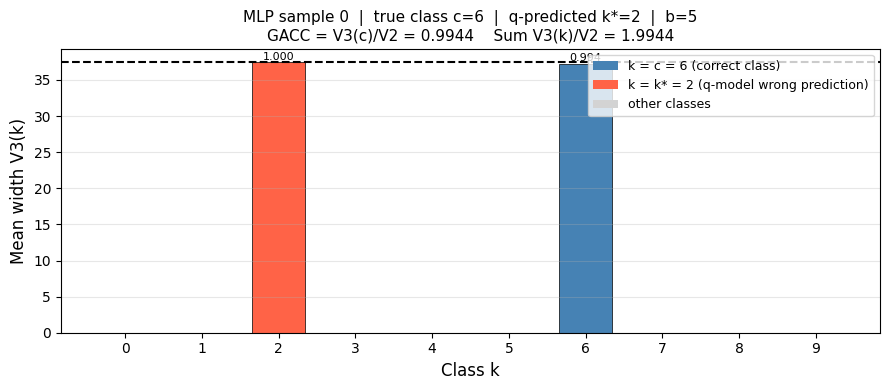

In [57]:
fig, ax = plt.subplots(figsize=(9, 4))

ks       = list(range(N_CLASSES))
v3_vals  = [V3[k] for k in ks]
colors   = ["steelblue" if k == c else ("tomato" if k == K_STAR else "lightgray")
            for k in ks]

bars = ax.bar(ks, v3_vals, color=colors, width=0.7, edgecolor="black", linewidth=0.5)
ax.axhline(V2, color="black", linewidth=1.5, linestyle="--", label=f"V2 = {V2:.3f}")

ax.set_xlabel("Class k", fontsize=12)
ax.set_ylabel("Mean width V3(k)", fontsize=12)
ax.set_title(
    f"MLP sample {SAMPLE_IDX}  |  true class c={c}  |  q-predicted k*={K_STAR}  |  b={BITS}\n"
    f"GACC = V3(c)/V2 = {GACC:.4f}    Sum V3(k)/V2 = {V3_sum/V2:.4f}",
    fontsize=11
)
ax.set_xticks(ks)
ax.legend(fontsize=10)
ax.grid(True, axis="y", alpha=0.3)

# Annotate each bar
for k, v in zip(ks, v3_vals):
    if v > 0.001 * V2:
        ax.text(k, v + 0.002 * V2, f"{v/V2:.3f}", ha="center", va="bottom", fontsize=8)

# Legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="steelblue", label=f"k = c = {c} (correct class)"),
    Patch(facecolor="tomato",    label=f"k = k* = {K_STAR} (q-model wrong prediction)"),
    Patch(facecolor="lightgray", label="other classes"),
]
ax.legend(handles=legend_elements, fontsize=9, loc="upper right")

plt.tight_layout()
plt.savefig(ROOT / "results" / "sanity_check_V3k.pdf", bbox_inches="tight")
print("Saved to results/sanity_check_V3k.pdf")
plt.show()